In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
netflix=pd.read_csv("C:\\Users\\dawit\\PycharmProjects\\Netflix Content Evolution\\data\\netflix_cleaned.csv")

In [3]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021


In [4]:
netflix['date_added']=pd.to_datetime(netflix['date_added'].str.strip())

In [5]:
netflix.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
added_year               int64
dtype: object

In [6]:
netflix['rating'].head(20)

0     PG-13
1     TV-MA
2     TV-MA
3     TV-MA
4     TV-MA
5     TV-MA
6        PG
7     TV-MA
8     TV-14
9     PG-13
10    TV-MA
11    TV-MA
12    TV-MA
13    TV-PG
14    TV-MA
15    TV-MA
16    TV-MA
17    TV-MA
18    TV-14
19    TV-MA
Name: rating, dtype: str

In [7]:
netflix['rating'].info()

<class 'pandas.Series'>
RangeIndex: 8797 entries, 0 to 8796
Series name: rating
Non-Null Count  Dtype
--------------  -----
8790 non-null   str  
dtypes: str(1)
memory usage: 68.9 KB


In [8]:
netflix['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [9]:
netflix=netflix[~(netflix['rating'].isna())]
netflix.shape

(8790, 13)

In [10]:
pd.get_dummies(netflix,columns=['type'],dtype=int).groupby('rating').agg({'type_TV Show':'sum','type_Movie':'sum'})

,type_TV Show,type_Movie
rating,,
G,0,41
NC-17,0,3
NR,4,75
PG,0,287
PG-13,0,490
R,2,797
TV-14,730,1427
TV-G,94,126
TV-MA,1143,2062


In [11]:
netflix_movies=netflix[netflix['type']=='Movie']
netflix_movies.shape

(6126, 13)

In [12]:
netflix_movies['rating'].value_counts()

rating
TV-MA       2062
TV-14       1427
R            797
TV-PG        540
PG-13        490
PG           287
TV-Y7        139
TV-Y         131
TV-G         126
NR            75
G             41
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64

In [13]:
netflix_movies_rating_by_year=pd.get_dummies(netflix_movies,columns=['rating'],dtype=int).groupby('added_year').sum(numeric_only=True).drop(columns='release_year')
netflix_movies_rating_by_year

,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
added_year,,,,,,,,,,,,,,
2008,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2009,0,0,0,0,0,0,0,0,2,0,0,0,0,0
2010,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2011,0,0,0,0,0,0,5,0,3,5,0,0,0,0
2012,0,0,0,1,0,1,0,0,0,1,0,0,0,0
2013,0,0,3,1,0,0,0,1,1,0,0,0,0,0
2014,1,0,0,3,0,0,2,0,9,3,1,0,0,0
2015,1,0,5,2,2,3,9,3,24,2,3,1,1,0
2016,2,1,27,3,6,13,40,2,114,25,1,16,1,0


In [14]:
netflix_movies_rating_proportion=netflix_movies_rating_by_year.div(netflix_movies_rating_by_year.sum(axis=1),axis=0)*100
netflix_movies_rating_proportion

,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
added_year,,,,,,,,,,,,,,
2008,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2009,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,38.461538,0.000000,23.076923,38.461538,0.000000,0.000000,0.000000,0.000000
2012,0.000000,0.000000,0.000000,33.333333,0.000000,33.333333,0.000000,0.000000,0.000000,33.333333,0.000000,0.000000,0.000000,0.000000
2013,0.000000,0.000000,50.000000,16.666667,0.000000,0.000000,0.000000,16.666667,16.666667,0.000000,0.000000,0.000000,0.000000,0.000000
2014,5.263158,0.000000,0.000000,15.789474,0.000000,0.000000,10.526316,0.000000,47.368421,15.789474,5.263158,0.000000,0.000000,0.000000
2015,1.785714,0.000000,8.928571,3.571429,3.571429,5.357143,16.071429,5.357143,42.857143,3.571429,5.357143,1.785714,1.785714,0.000000
2016,0.796813,0.398406,10.756972,1.195219,2.390438,5.179283,15.936255,0.796813,45.418327,9.960159,0.398406,6.374502,0.398406,0.000000


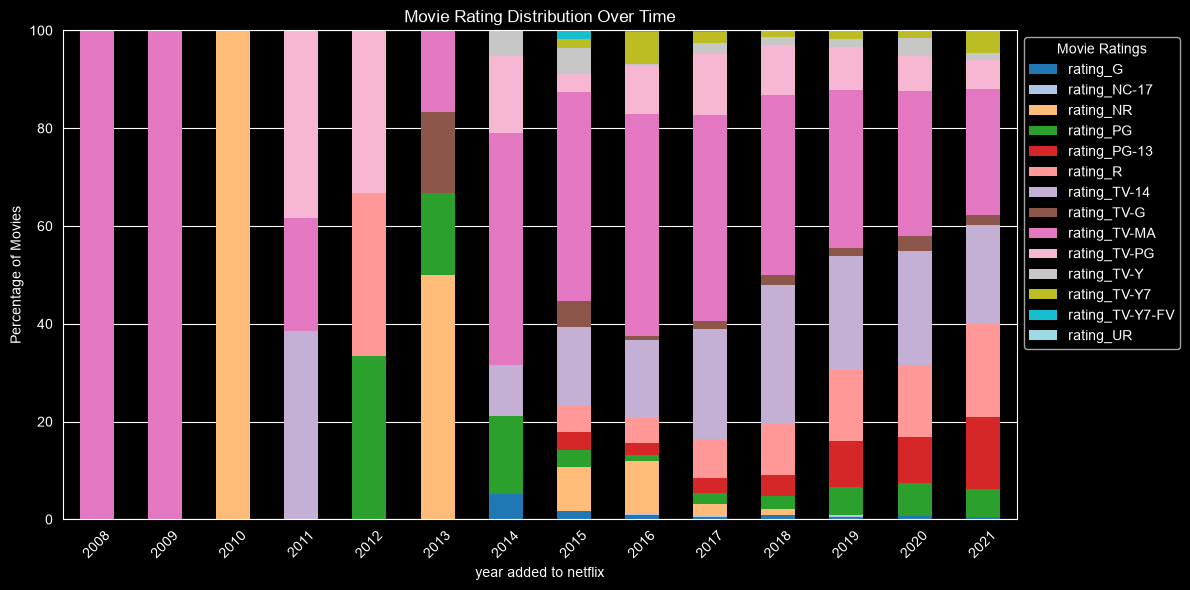

In [15]:
netflix_movies_rating_proportion.plot(kind='bar',stacked=True,figsize=(12,6),edgecolor='none',colormap='tab20')
plt.title('Movie Rating Distribution Over Time')
plt.xlabel('year added to netflix')
plt.ylabel('Percentage of Movies')
plt.legend(title='Movie Ratings',loc='upper left',bbox_to_anchor=(1,1))
plt.xticks(rotation=45)
plt.tight_layout()

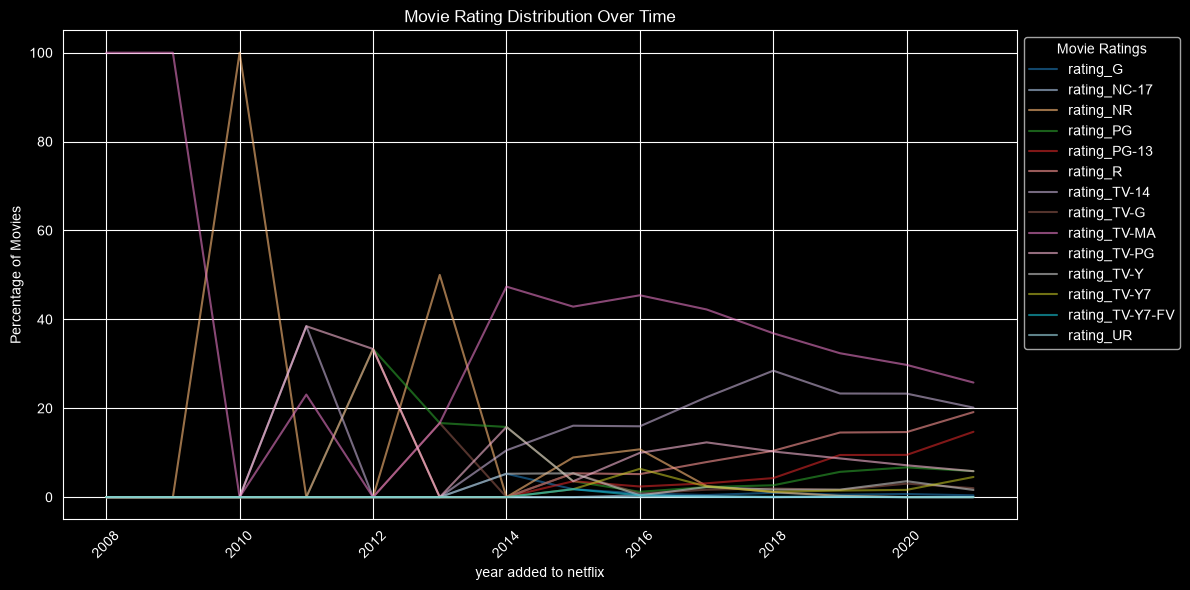

In [16]:
netflix_movies_rating_proportion.plot(figsize=(12,6),colormap='tab20',alpha=0.6)
plt.title('Movie Rating Distribution Over Time')
plt.xlabel('year added to netflix')
plt.ylabel('Percentage of Movies')
plt.legend(title='Movie Ratings',loc='upper left',bbox_to_anchor=(1,1))
plt.xticks(rotation=45)
plt.tight_layout()

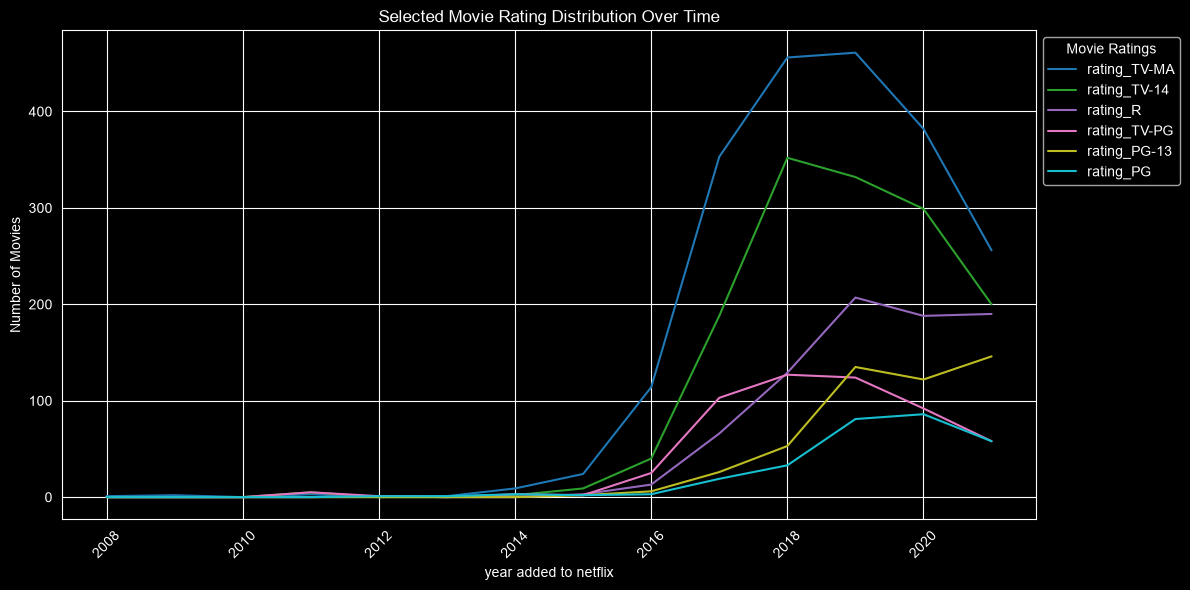

In [17]:
netflix_movies_rating_by_year.plot(y=[
    'rating_TV-MA',
    'rating_TV-14',
    'rating_R',
    'rating_TV-PG',
    'rating_PG-13',
    'rating_PG'
],figsize=(12,6),colormap='tab10')
plt.title('Selected Movie Rating Distribution Over Time')
plt.xlabel('year added to netflix')
plt.ylabel('Number of Movies')
plt.legend(title='Movie Ratings',loc='upper left',bbox_to_anchor=(1,1))
plt.xticks(rotation=45)
plt.tight_layout()

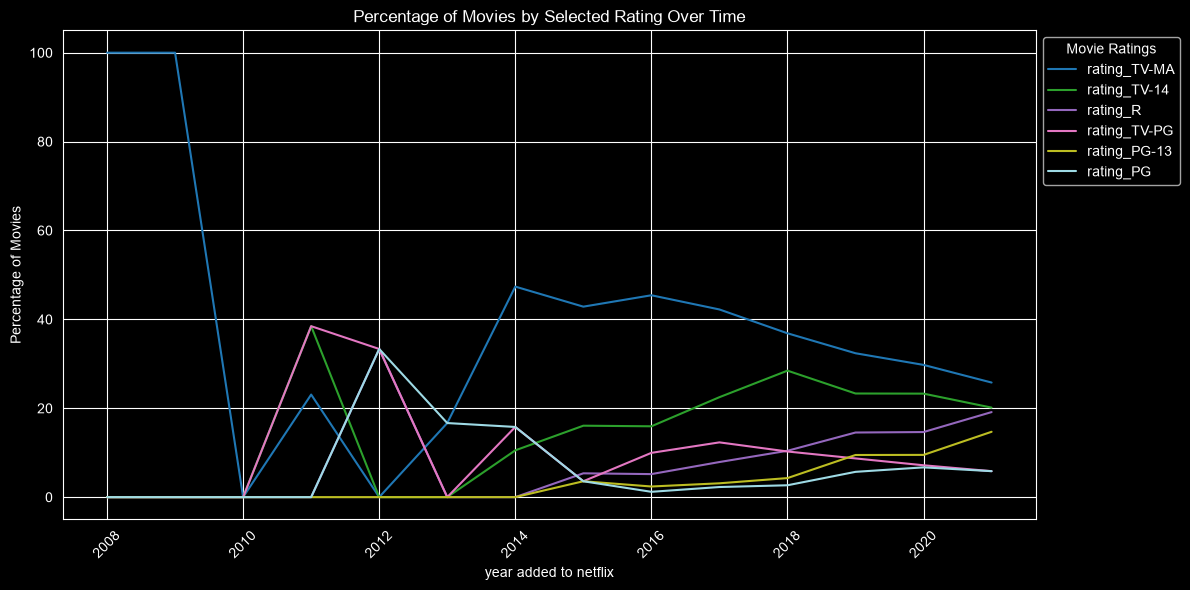

In [18]:
netflix_movies_rating_proportion.plot(y=[
    'rating_TV-MA',
    'rating_TV-14',
    'rating_R',
    'rating_TV-PG',
    'rating_PG-13',
    'rating_PG'
],figsize=(12,6),colormap='tab20')
plt.title('Percentage of Movies by Selected Rating Over Time')
plt.xlabel('year added to netflix')
plt.ylabel('Percentage of Movies')
plt.legend(title='Movie Ratings',loc='upper left',bbox_to_anchor=(1,1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:\\Users\\dawit\\PycharmProjects\\Netflix Content Evolution\\images\\Movies_By_Selected_Rating.png',dpi=300,bbox_inches='tight')

In [19]:
netflix_tv_shows=netflix[netflix['type']=='TV Show']
netflix_tv_shows.shape

(2664, 13)

In [20]:
netflix_tv_shows['rating'].value_counts()

rating
TV-MA       1143
TV-14        730
TV-PG        321
TV-Y7        194
TV-Y         175
TV-G          94
NR             4
R              2
TV-Y7-FV       1
Name: count, dtype: int64

In [21]:
netflix_tv_shows_rating_by_year=pd.get_dummies(netflix_tv_shows,columns=['rating'],dtype=int).groupby('added_year').sum(numeric_only=True).drop(columns='release_year')
netflix_tv_shows_rating_by_year

,rating_NR,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV
added_year,,,,,,,,,
2008,0,0,0,0,1,0,0,0,0
2013,1,0,2,0,2,0,0,0,0
2014,0,0,0,1,3,1,0,0,0
2015,0,0,5,2,5,6,4,3,1
2016,0,1,58,7,48,25,9,27,0
2017,3,0,138,9,93,65,16,25,0
2018,0,0,99,12,194,57,19,30,0
2019,0,1,162,17,275,74,30,33,0
2020,0,0,140,22,289,54,56,34,0


In [22]:
netflix_tv_shows_rating_proportion=netflix_tv_shows_rating_by_year.div(netflix_tv_shows_rating_by_year.sum(axis=1),axis=0)*100
netflix_tv_shows_rating_proportion

,rating_NR,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV
added_year,,,,,,,,,
2008,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000
2013,20.000000,0.000000,40.000000,0.000000,40.000000,0.000000,0.000000,0.000000,0.000000
2014,0.000000,0.000000,0.000000,20.000000,60.000000,20.000000,0.000000,0.000000,0.000000
2015,0.000000,0.000000,19.230769,7.692308,19.230769,23.076923,15.384615,11.538462,3.846154
2016,0.000000,0.571429,33.142857,4.000000,27.428571,14.285714,5.142857,15.428571,0.000000
2017,0.859599,0.000000,39.541547,2.578797,26.647564,18.624642,4.584527,7.163324,0.000000
2018,0.000000,0.000000,24.087591,2.919708,47.201946,13.868613,4.622871,7.299270,0.000000
2019,0.000000,0.168919,27.364865,2.871622,46.452703,12.500000,5.067568,5.574324,0.000000
2020,0.000000,0.000000,23.529412,3.697479,48.571429,9.075630,9.411765,5.714286,0.000000


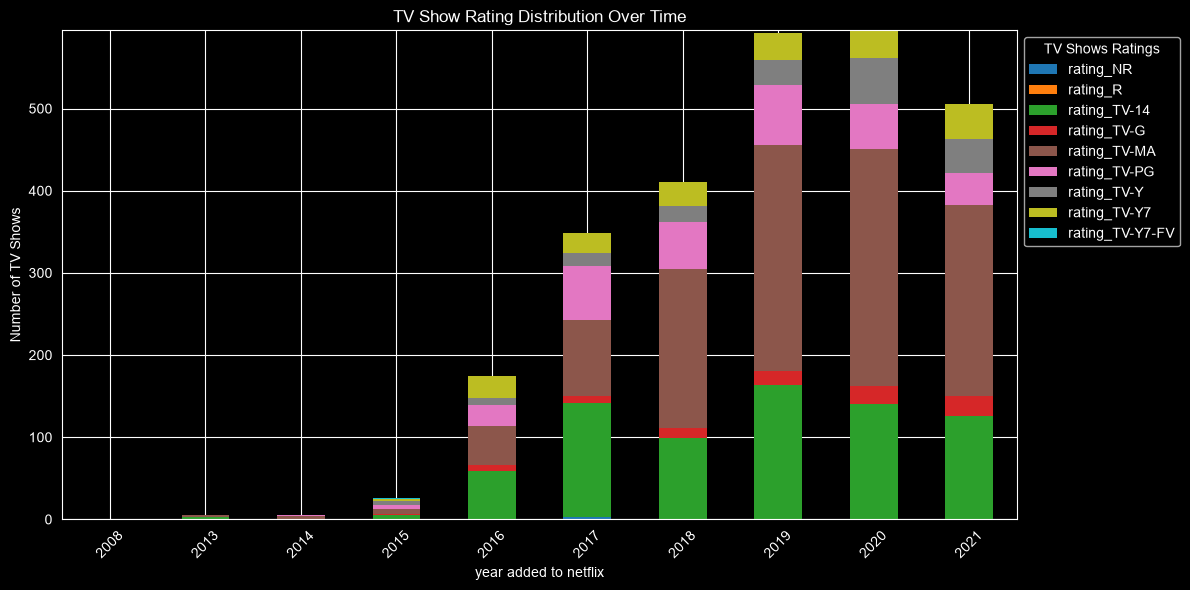

In [23]:
netflix_tv_shows_rating_by_year.plot(kind='bar',stacked=True,figsize=(12,6),edgecolor='none',colormap='tab10')
plt.title('TV Show Rating Distribution Over Time')
plt.xlabel('year added to netflix')
plt.ylabel('Number of TV Shows')
plt.legend(title='TV Shows Ratings',loc='upper left',bbox_to_anchor=(1,1))
plt.xticks(rotation=45)
plt.tight_layout()

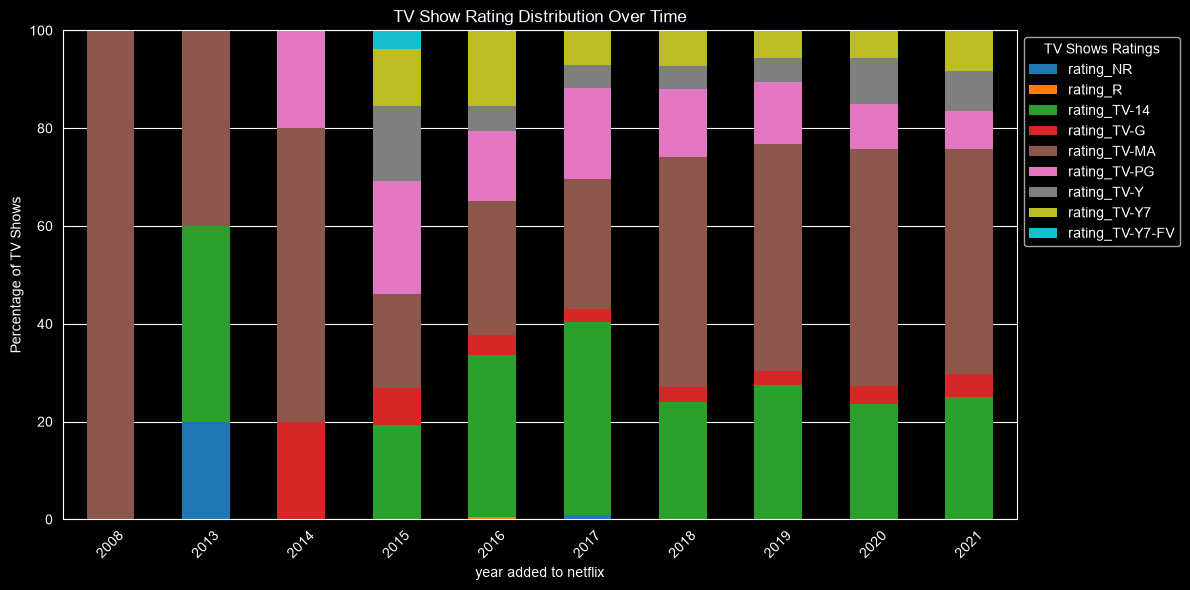

In [24]:
netflix_tv_shows_rating_proportion.plot(kind='bar',stacked=True,figsize=(12,6),edgecolor='none',colormap='tab10')
plt.title('TV Show Rating Distribution Over Time')
plt.xlabel('year added to netflix')
plt.ylabel('Percentage of TV Shows')
plt.legend(title='TV Shows Ratings',loc='upper left',bbox_to_anchor=(1,1))
plt.xticks(rotation=45)
plt.tight_layout()

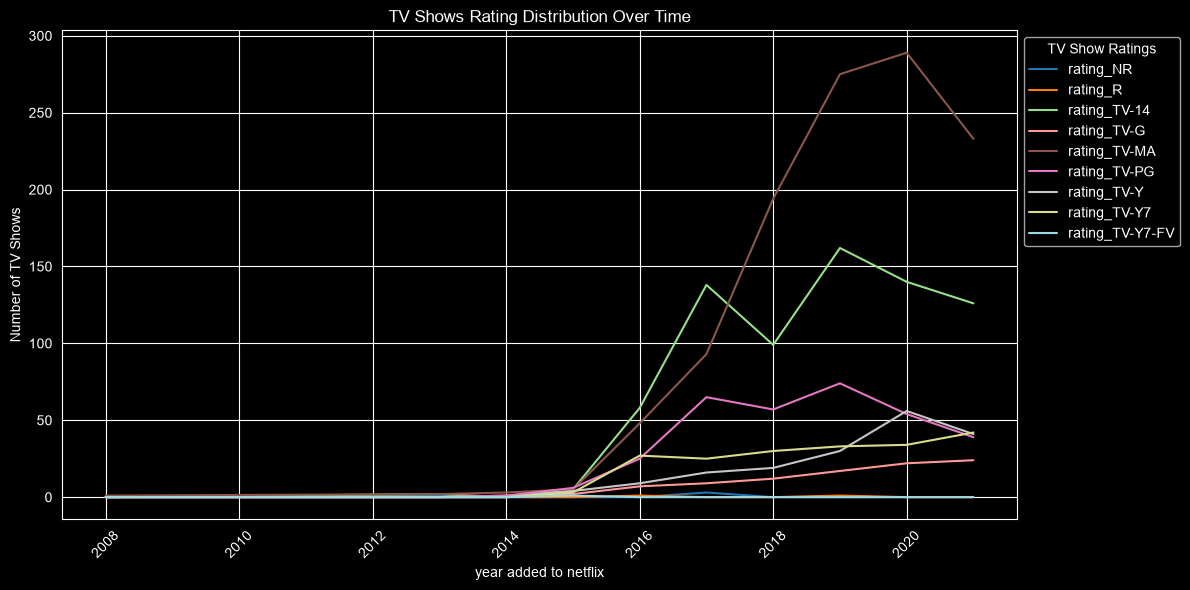

In [25]:
netflix_tv_shows_rating_by_year.plot(figsize=(12,6),colormap='tab20')
plt.title('TV Shows Rating Distribution Over Time')
plt.xlabel('year added to netflix')
plt.ylabel('Number of TV Shows')
plt.legend(title='TV Show Ratings',loc='upper left',bbox_to_anchor=(1,1))
plt.xticks(rotation=45)
plt.tight_layout()

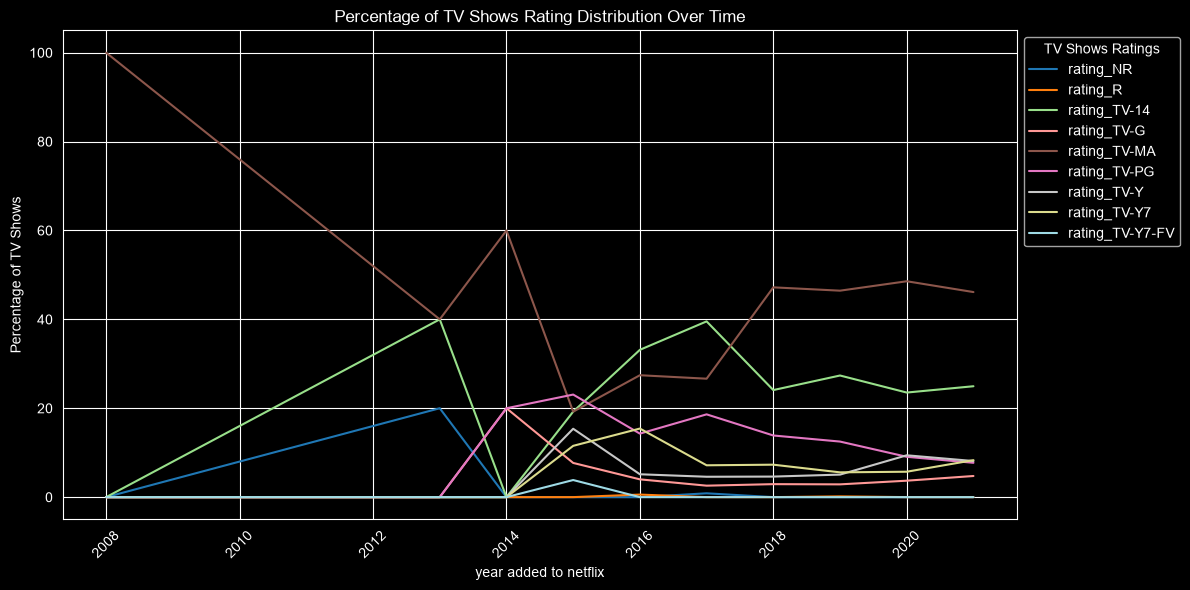

In [26]:
netflix_tv_shows_rating_proportion.plot(figsize=(12,6),colormap='tab20')
plt.title('Percentage of TV Shows Rating Distribution Over Time')
plt.xlabel('year added to netflix')
plt.ylabel('Percentage of TV Shows')
plt.legend(title='TV Shows Ratings',loc='upper left',bbox_to_anchor=(1,1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:\\Users\\dawit\\PycharmProjects\\Netflix Content Evolution\\images\\TV_Shows_Rating.png',dpi=300,bbox_inches='tight')